In [127]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid

import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
%matplotlib inline

In [128]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
train_transform =  transforms.Compose([
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [129]:
train_data = datasets.FashionMNIST(root='/fashionMNIST', download=True, train=True, transform=transform)

In [130]:
test_data = datasets.FashionMNIST(root='/fashionMNIST', download=True, train=False, transform=transform)

In [131]:
train_data

Dataset FashionMNIST
    Number of datapoints: 60000
    Root location: /fashionMNIST
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.5,), std=(0.5,))
           )

In [132]:
test_data

Dataset FashionMNIST
    Number of datapoints: 10000
    Root location: /fashionMNIST
    Split: Test
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.5,), std=(0.5,))
           )

In [133]:
batch_size = 64
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

In [134]:
class ConvolutionalNeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 6, 3, 1)
        self.conv2 = nn.Conv2d(6, 16, 3, 1)

        self.fc1 = nn.Linear(5*5*16, 124)
        self.fc2 = nn.Linear(124, 62)
        self.fc3 = nn.Linear(62, 10)

    def forward(self, X):
        X = F.relu(self.conv1(X))
        X = F.max_pool2d(X, 2, 2)
        X = F.relu(self.conv2(X))
        X = F.max_pool2d(X, 2, 2)

        X = X.view(-1, 16*5*5)

        X = F.relu(self.fc1(X))
        X = F.relu(self.fc2(X))
        X = self.fc3(X)

        return X

In [135]:
torch.manual_seed(41)
model = ConvolutionalNeuralNetwork()
model

ConvolutionalNeuralNetwork(
  (conv1): Conv2d(1, 6, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=124, bias=True)
  (fc2): Linear(in_features=124, out_features=62, bias=True)
  (fc3): Linear(in_features=62, out_features=10, bias=True)
)

In [136]:
criterion = nn.CrossEntropyLoss() 
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [137]:
import time 

epochs = 5
train_losses = []
test_losses = []
train_correct = []
test_correct = []

start_time = time.time()

for i in range(epochs):
    trn_corr = 0
    tst_corr = 0
    for b, (X_train, y_train) in enumerate(train_loader):
        b += 1
        y_val = model(X_train)
        loss = criterion(y_val, y_train)

        predicted = torch.argmax(y_val.data, 1)
        batch_correct = (predicted == y_train).sum()
        trn_corr += batch_correct

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if b % 100 == 0:
            print(f'Epoch: {i} loss: {loss.item()}')

    train_losses.append(loss)
    train_correct.append(trn_corr)

    with torch.no_grad():
        for b, (X_test, y_test) in enumerate(test_loader):
            y_val = model(X_test)
            loss = criterion(y_val, y_test)

            predicted = torch.argmax(y_val.data, 1)
            batch_correct = (predicted == y_test).sum()
            tst_corr += batch_correct

        test_correct.append(tst_corr)
        test_losses.append(loss)

current_time = time.time()
total_time = current_time - start_time
print(f'the model took {total_time/60} minutes for training')

Epoch: 0 loss: 0.8540370464324951
Epoch: 0 loss: 0.6252431869506836
Epoch: 0 loss: 0.4888611137866974
Epoch: 0 loss: 0.5877493619918823
Epoch: 0 loss: 0.4199807047843933
Epoch: 0 loss: 0.5178684592247009
Epoch: 0 loss: 0.6824091672897339
Epoch: 0 loss: 0.44130587577819824
Epoch: 0 loss: 0.510457456111908
Epoch: 1 loss: 0.41960543394088745
Epoch: 1 loss: 0.48792967200279236
Epoch: 1 loss: 0.387871652841568
Epoch: 1 loss: 0.4410284757614136
Epoch: 1 loss: 0.42227938771247864
Epoch: 1 loss: 0.3439372479915619
Epoch: 1 loss: 0.2703794538974762
Epoch: 1 loss: 0.2310512363910675
Epoch: 1 loss: 0.3719901740550995
Epoch: 2 loss: 0.30170607566833496
Epoch: 2 loss: 0.46570518612861633
Epoch: 2 loss: 0.4080624282360077
Epoch: 2 loss: 0.3551614284515381
Epoch: 2 loss: 0.24676893651485443
Epoch: 2 loss: 0.3393521308898926
Epoch: 2 loss: 0.38675010204315186
Epoch: 2 loss: 0.36284446716308594
Epoch: 2 loss: 0.20973236858844757
Epoch: 3 loss: 0.3690621852874756
Epoch: 3 loss: 0.29860571026802063
Epoch

In [138]:
Full_test_data = DataLoader(test_data, batch_size=10000, shuffle=False)

In [139]:
with torch.no_grad():
    correct = 0
    for X_test, y_test in Full_test_data:
        y_pred = model(X_test)
        predicted = torch.argmax(y_pred, 1)
        correct += (predicted == y_test).sum()

In [140]:
correct.item()/len(test_data)*100

88.24

7

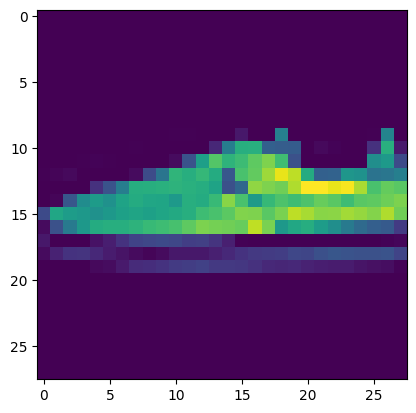

In [141]:
plt.imshow(test_data[1119][0].reshape(28,28))
test_data[1119][1]

In [142]:
with torch.no_grad():
    model.eval()
    new_prediction = model(test_data[1119][0].view(1,1,28,28))
new_prediction.argmax().item()

7